In [3]:
from pathlib import Path

def get_file_list(folder_path, pattern="*.tsv", recursive=False):
    """
    Restituisce la lista di file (percorsi stringa) nella cartella `folder_path`
    che corrispondono al glob `pattern`. Se recursive=True usa rglob().
    """
    p = Path(folder_path)
    if not p.exists():
        raise FileNotFoundError(f"Cartella non trovata: {folder_path}")
    if not p.is_dir():
        raise NotADirectoryError(f"Non è una cartella: {folder_path}")

    if recursive:
        files = sorted([f for f in p.rglob(pattern) if f.is_file()])
    else:
        files = sorted([f for f in p.glob(pattern) if f.is_file()])

    return [str(f) for f in files]

# --- Impostare qui il percorso della cartella ---
folder_path = "./misure_interessanti/submatrix"  
# pattern può essere "*.tsv", "*.*", "*.txt", ecc.
file_list = get_file_list(folder_path, pattern="*.tsv", recursive=False)

print(f"Trovati {len(file_list)} file in {folder_path}")
# file_list è pronto per essere usato nelle celle successive (es. la cella che legge i file)

Trovati 4 file in ./misure_interessanti/submatrix


In [ ]:
import re
import pandas as pd


def parse_falaphel_filename(file_path):
    """Estrae parametri da nome file tipo:
        data_falaphel_prin_<timestamp><suffix_string>[_]x[_]<pixel_x>[_]y[_]<pixel_y>.tsv
    """
    file_name = Path(file_path).name
    
# 1. Trova il suffisso e le coordinate del pixel (ora opzionali/fisse).
    
    # Nuovo pattern: cerca un suffisso che termina con "_submatrix.tsv"
    # m_new cerca: (tutto il resto) + (_submatrix) + (.tsv)
    m_new = re.search(r'(.+?)_submatrix\.tsv$', file_name)

    if m_new:
        # Se trova il pattern _submatrix.tsv, usa 0 per x e y
        suffix = m_new.group(1)
        config = {
            'pixel_x': 0, # Valore di default se non ci sono coordinate x/y
            'pixel_y': 0, # Valore di default se non ci sono coordinate x/y
        }
    else:
        # Vecchio pattern: cerca le coordinate x e y (se il file_name non finisce con _submatrix.tsv)
        # Pattern flessibile: (...suffix) + (_?x_?) + (num) + (_?y_?) + (num) + .tsv
        m_old = re.search(r'(.+?)[_]?x[_]?(\d+)[_]?y[_]?(\d+)\.tsv$', file_name)
        
        if not m_old:
            # Se non trova né il nuovo né il vecchio pattern, ritorna None
            return None
            
        suffix = m_old.group(1)
        config = {
            'pixel_x': int(m_old.group(2)),
            'pixel_y': int(m_old.group(3)),
        }
    # 2. dac_th (supporta 'dacth<num>' O 'dacth_<num>')
    dac_th_m = re.search(r'dacth_?(\d+)', suffix)
    config['dac_th'] = int(dac_th_m.group(1)) if dac_th_m else 0

    # 3. flag booleani (rimane invariato)
    for flag in ("cap50", "cap25", "cap_csa_load", "t_up"):
        config[flag] = 1 if flag in suffix else 0

    # 4. timestamp (opzionale)
    ts_m = re.search(r'_prin_(\d{12})', file_name)
    if ts_m:
        config['timestamp'] = ts_m.group(1)

    return config

all_data = []
if not file_list:
    print("Nessun file nella lista.")
else:
    print(f"Trovati {len(file_list)} file. Procedo a leggere e parsare...")
    for fp in file_list:
        cfg = parse_falaphel_filename(fp)
        if cfg is None:
            print(f"❌ Impossibile parsare il nome: {fp}")
            continue
        try:
            df = pd.read_csv(fp, sep='\t')
            
            # 🚨 Rimuovi le righe dove 'voltage' è 103
            initial_rows = len(df)
            df = df[df['voltage'] != 103]
            rows_removed = initial_rows - len(df)
            
            if rows_removed > 0:
                print(f"File {Path(fp).name}: rimosse {rows_removed} righe con voltage = 103.")

            # aggiungi colonne di configurazione
            for k, v in cfg.items():
                df[k] = v
            df['file_name'] = Path(fp).name
            all_data.append(df)
        except Exception as e:
            print(f"⚠️ Errore leggendo {fp}: {e}")

if all_data:
    df_combined = pd.concat(all_data, ignore_index=True)
    print(f"\nCombinazione completata: {len(df_combined)} righe, {len(df_combined.columns)} colonne.")
    display(df_combined.head())
else:
    print("Nessun dato caricato con successo.")

#salva il dataframe combinato in un file excel
#output_excel_path = "combined_falaphel_data.xlsx"
#df_combined.to_excel(output_excel_path, index=False)
#print(f"Dati combinati salvati in {output_excel_path}.")


Trovati 4 file. Procedo a leggere e parsare...

Combinazione completata: 4000 righe, 17 colonne.


,col,row,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa,pixel_x,pixel_y,dac_th,cap50,cap25,cap_csa_load,t_up,file_name
0,3,3,100,5.000,0.000,11.613,0.495,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
1,3,3,97,5.000,0.000,11.742,0.445,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
2,3,3,94,5.000,0.000,11.935,0.250,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
3,3,3,91,4.935,0.250,12.000,0.000,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
4,3,3,88,4.645,0.486,12.000,0.000,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...


In [ ]:
# filtro per la configurazione richiesta: cap50=1, cap25=0, t_up=0, cap_csa_load=0
df_cap50_config = df_combined.loc[
    (df_combined['cap50'] == 1) &
    (df_combined['cap25'] == 0) &
    (df_combined['t_up'] == 0) &
    (df_combined['cap_csa_load'] == 0)
].copy()

print(f"Trovate {len(df_cap50_config)} righe nella configurazione cap50=1, cap25=0, t_up=0, cap_csa_load=0")
display(df_cap50_config.head())

Trovate 1000 righe nella configurazione cap50=1, cap25=0, t_up=0, cap_csa_load=0


,col,row,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa,pixel_x,pixel_y,dac_th,cap50,cap25,cap_csa_load,t_up,file_name
0,3,3,100,5.000,0.000,11.613,0.495,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
1,3,3,97,5.000,0.000,11.742,0.445,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
2,3,3,94,5.000,0.000,11.935,0.250,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
3,3,3,91,4.935,0.250,12.000,0.000,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...
4,3,3,88,4.645,0.486,12.000,0.000,1.0,1.0,0,0,0,1,0,0,0,export_matrix_scan_251110_163602_cap50_submatr...


In [ ]:
import numpy as np
import pandas as pd
from scipy.special import erf
from scipy.optimize import curve_fit

# 1. Modello ERF S-curve
def myERF(x, mu, sigma):
    """
    Modello matematico per la S-curve (Funzione di Errore).
    mu è la soglia (threshold), sigma è la dispersione (noise/width).
    """
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))


def plot_erf_curve(xdata, ydata, popt, row, col, metric):
    """
    Funzione per plottare i dati e la curva di fit ERF.
    
    Args:
        xdata (np.ndarray): Dati x (voltage).
        ydata (np.ndarray): Dati y (efficiency).
        popt (list): Parametri ottimali del fit [mu, sigma].
        row (int): Riga del pixel.
        col (int): Colonna del pixel.
        metric (str): Nome della metrica (colonna) usata.
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.scatter(xdata, ydata, label='Dati', color='blue')
    
    # Genera punti per la curva di fit
    x_fit = np.linspace(min(xdata), max(xdata), 100)
    y_fit = myERF(x_fit, *popt)
    
    plt.plot(x_fit, y_fit, label='Fit ERF', color='red')
    plt.title(f'Fit ERF per Pixel (Row: {row}, Col: {col}) - Metrica: {metric}')
    plt.xlabel('Voltage')
    plt.ylabel('Efficiency')
    plt.legend()
    plt.grid()
    plt.show()

   
    
# 2. Funzione principale per l'elaborazione del DataFrame
def fit_erf_to_scurves(df, cols=["efficiency_toa"]):
    """
    Esegue il fit della S-curve ERF sui dati raggruppati per pixel.

    Args:
        df (pd.DataFrame): DataFrame contenente i dati,
                           deve avere colonne 'row', 'col', 'voltage', e le colonne in 'cols'.
        cols (list): Lista delle colonne metriche su cui eseguire il fit (es. ['efficiency_toa']).

    Returns:
        pd.DataFrame: DataFrame con i risultati del fit (threshold, dispersion, successo).
    """
    results = []
    
    # 2.1. Raggruppa i dati per pixel (row, col)
    for (r, c), group in df.groupby(["row", "col"]):
        
        # 2.2. Itera su tutte le colonne metriche specificate
        for col in cols:
            if col not in group.columns:
                continue

            # Prepara i dati
            valid = group[["voltage", col]].dropna()
            npts = len(valid)

            # Controllo minimo punti per il fit
            if npts < 4:
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )
                continue

            xdata = valid["voltage"].values
            ydata = valid[col].values

            # Stima iniziale dei parametri (guess)
            # mu: mediana della tensione. sigma: un quarto del range della tensione.
            guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
            
            # 2.3. Esegue il fit
            try:
                popt, pcov = curve_fit(
                    myERF,
                    xdata,
                    ydata,
                    p0=guess,
                    # Assicura che sigma (dispersione) sia > 0
                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                    maxfev=5000,
                )
                fit_mu, fit_sigma = float(popt[0]), float(popt[1])
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
                )

                # Opzionale: plottare il fit per ogni pixel
                #plot_erf_curve(xdata, ydata, popt, r, c, col)
                plot_erf_curvefit_overlapped(xdata, ydata, popt, r, c, col)
            except Exception:
                # Gestione dell'errore nel fit
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )

    # 2.4. Ritorna il DataFrame dei risultati
    return pd.DataFrame(results)



# ----------------------------------------------------------------------
# Esempio di Utilizzo:
# ----------------------------------------------------------------------

# Assumendo che 'df_combined' sia il tuo DataFrame finale
# df = df_combined 

# # Esegui la funzione con la colonna 'efficiency_toa'
# fit_results_df = fit_erf_to_scurves(df, cols=["efficiency_toa", "efficiency_tot"])

# print(f"Fit completato per {len(fit_results_df)} record.")
# display(fit_results_df.head())
# # Salvataggio opzionale:
# # fit_results_df.to_csv("fit_results_per_pixel.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf
import matplotlib.pyplot as plt

# 1. Funzione ERF (S-Curve)
# Assumiamo che myERF sia definita in questo modo per l'S-curve (integral della Gaussiana)
def myERF(x, mu, sigma):
    """Funzione di errore (ERF) per il fit dell'S-curve."""
    # Modello tipico: 0.5 * (1 + erf((x - mu) / (sigma * sqrt(2))))
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2))))

# 2. Nuova funzione per plottare una singola curva fittata su un oggetto Axes
def plot_single_fit_on_ax(ax, popt, r, c, col):
    """
    Disegna la curva ERF fittata sull'oggetto Axes fornito.
    """
    fit_mu, fit_sigma = popt[0], popt[1]
    
    # Crea 100 punti per un tracciato liscio della curva
    # Utilizza un range arbitrario o basato sui dati se noto
    x_fit = np.linspace(40, 60, 100)  # Modifica questo range se necessario
    y_fit = myERF(x_fit, fit_mu, fit_sigma)
    
    label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
    
    # Aggiungi il plot all'Axes
    ax.plot(x_fit, y_fit, alpha=0.5, label=label)


# 3. Funzione principale per l'elaborazione del DataFrame
def fit_erf_to_scurves(df, cols=["efficiency_toa"], plot_title="Sovrapposizione S-Curves Fittate"):
    """
    Esegue il fit della S-curve ERF sui dati raggruppati per pixel e crea un plot sovrapposto.

    Args:
        df (pd.DataFrame): DataFrame contenente i dati.
        cols (list): Lista delle colonne metriche su cui eseguire il fit.
        plot_title (str): Titolo per il plot di sovrapposizione.

    Returns:
        pd.DataFrame: DataFrame con i risultati del fit (threshold, dispersion, successo).
    """
    results = []
    
    # 3.1. Inizializzazione del plot per la sovrapposizione
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_title(plot_title)
    ax.set_xlabel("Voltage (Tensione)")
    ax.set_ylabel(f"Fit S-Curve ({', '.join(cols)})")
    
    # 3.2. Raggruppa i dati per pixel (row, col)
    for (r, c), group in df.groupby(["row", "col"]):
        
        # Itera su tutte le colonne metriche specificate
        for col in cols:
            if col not in group.columns:
                continue

            # Prepara i dati
            valid = group[["voltage", col]].dropna()
            npts = len(valid)

            # Controllo minimo punti per il fit
            if npts < 4:
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )
                continue

            xdata = valid["voltage"].values
            ydata = valid[col].values

            # Stima iniziale dei parametri (guess)
            guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
            
            # 3.3. Esegue il fit
            try:
                popt, pcov = curve_fit(
                    myERF,
                    xdata,
                    ydata,
                    p0=guess,
                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                    maxfev=5000,
                )
                fit_mu, fit_sigma = float(popt[0]), float(popt[1])
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
                )

                # 3.4. Aggiunge il fit al plot di sovrapposizione
                plot_single_fit_on_ax(ax, popt, r, c, col)
                
            except Exception as e:
                # Gestione dell'errore nel fit
                print(f"Fit fallito per pixel ({r}, {c}), metrica {col}: {e}")
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )

    # 3.5. Finalizzazione del plot (dopo il ciclo)
    # Rimuovi il codice per la legenda se il numero di curve è elevato, 
    # altrimenti potrebbe rendere il plot illeggibile.
    # Se vuoi solo un'idea della distribuzione, non mettere la legenda.
    
    # ax.legend(loc='best', fontsize='small') # Abilita se hai pochi pixel
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Salva il plot in un file (opzionale)
    #plt.savefig(f"{'_'.join(cols)}_overlapped_fits.png")
    
    # Mostra il plot (opzionale)
    plt.show() 
    
    plt.close(fig) # Chiudi la figura per liberare memoria

    # 3.6. Ritorna il DataFrame dei risultati
    return pd.DataFrame(results)

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\s'
C:\Users\andre\AppData\Local\Temp\ipykernel_8444\522994418.py:26: SyntaxWarning: invalid escape sequence '\m'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
C:\Users\andre\AppData\Local\Temp\ipykernel_8444\522994418.py:26: SyntaxWarning: invalid escape sequence '\s'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"


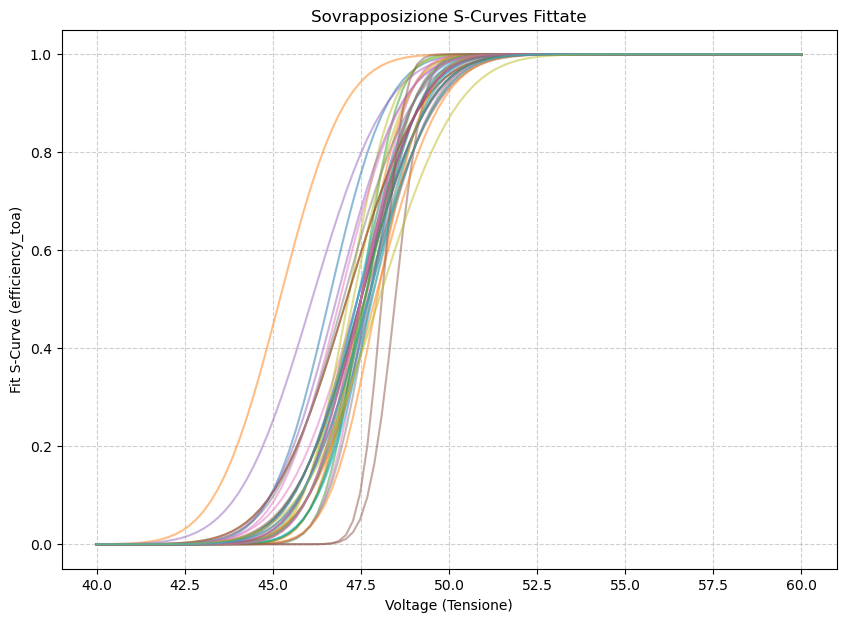

Fit completato per 40 record (config cap50=1).
Fit completato per 40 record (config cap50=1).


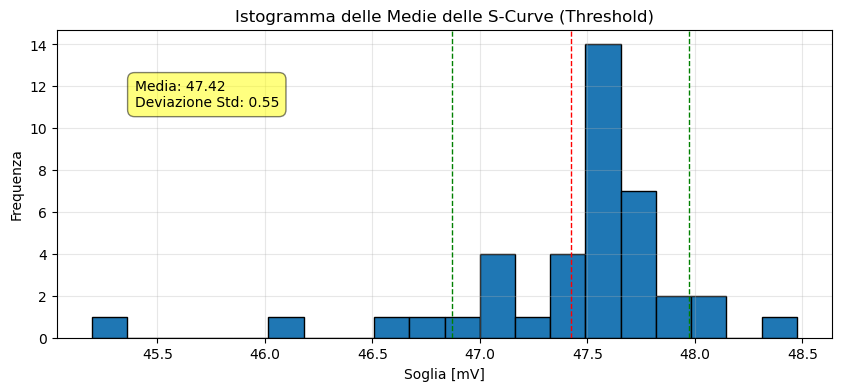

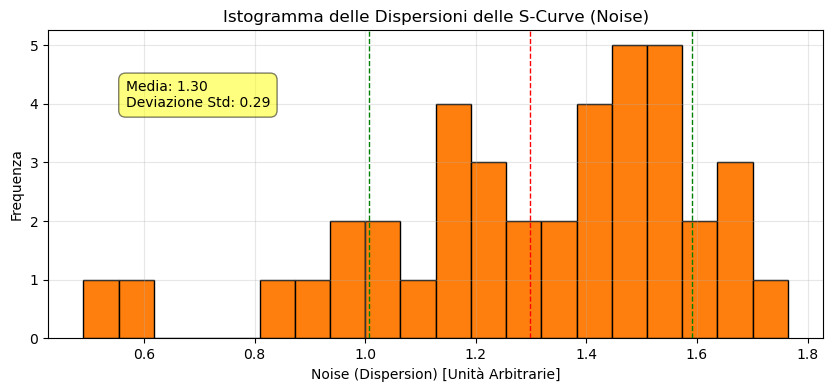

In [59]:
import matplotlib.pyplot as plt
import pandas as pd # Assumo che 'fit_results_df_50' sia un DataFrame Pandas
# from tuo_modulo import fit_erf_to_scurves # Decommenta se necessario

def plot_histogram_with_stats(data: pd.Series, title: str, xlabel: str, color: str):
    """
    Crea un istogramma per la serie di dati specificata e annota media e deviazione standard.

    Args:
        data (pd.Series): La serie di dati da plottare.
        title (str): Il titolo del grafico.
        xlabel (str): L'etichetta dell'asse X.
        color (str): Il colore delle barre dell'istogramma.
    """
    # Rimuovi i valori NaN prima del plot e del calcolo
    data_cleaned = data.dropna()

    plt.figure(figsize=(10, 4))
    plt.hist(data_cleaned, bins=20, color=color, edgecolor='k')

    # Calcola e annota media e deviazione standard
    mean_val = data_cleaned.mean()
    std_val = data_cleaned.std()

    # Aggiunge le linee per media e deviazioni standard
    plt.axvline(mean_val, color='r', linestyle='dashed', linewidth=1, label=f'Media: {mean_val:.2f}')
    plt.axvline(mean_val + std_val, color='g', linestyle='dashed', linewidth=1, label=f'1 $\\sigma$')
    plt.axvline(mean_val - std_val, color='g', linestyle='dashed', linewidth=1)

    # Annotazione con media e deviazione standard
    plt.gca().annotate(f"Media: {mean_val:.2f}\nDeviazione Std: {std_val:.2f}",
                       xy=(0.1, 0.75), xycoords='axes fraction',
                       bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5))

    plt.xlabel(xlabel)
    plt.ylabel('Frequenza')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()


################################
fit_results_df_50 = fit_erf_to_scurves(df_cap50_config, cols=["efficiency_toa"])
print(f"Fit completato per {len(fit_results_df_50)} record (config cap50=1).")

print(f"Fit completato per {len(fit_results_df_50)} record (config cap50=1).")

# 2. Plot dell'Istogramma per la Soglia (Threshold)
plot_histogram_with_stats(
    data=fit_results_df_50['threshold'],
    title='Istogramma delle Medie delle S-Curve (Threshold)',
    xlabel='Soglia [mV]',
    color='C0'
)

# 3. Plot dell'Istogramma per la Dispersione (Noise)
plot_histogram_with_stats(
    data=fit_results_df_50['dispersion'],
    title='Istogramma delle Dispersioni delle S-Curve (Noise)',
    xlabel='Noise (Dispersion) [Unità Arbitrarie]', # Modificato per chiarezza
    color='C1'
)